In [1]:
import numpy as np 
import qutip as qt
import ufss as uf

# 2. La spectroscopie 2D
from qudpy.Classes import System
import qudpy.plot_functions as pf

# Physic constant and definition of parameter


In [2]:
hbar = 0.658211951 # hbar in eV*fs

E_elec= 1.5 # d-d transition energy
E_vib = 0.040 # Phonon énergie

S=2.5 # Facteur de Hunag-Rhys (For Frank-condon approximation)
lambda_HT= 0.5 # Coupling parameter Herzberg-Teller modele

w_e = E_elec / hbar #electronic transition frequency
w_v = E_vib / hbar #phonon transition frequency
N_fock = 5 # number of phonon mode. 

# Operator definition 

1. qt.tensor $\newline$ This function combines operators acting on different subsystems to create a global operator.

- Example: If space A has dimension $N$ and space B has dimension $M$, qt.tensor(A, B) creates a matrix of dimension $(N \times M)$.

2. Bosonic Mode OperatorsThese lines define the annihilation operator for a bosonic mode.

- qt.destroy(N_fock): $\newline$
Creates the annihilation operator $a$ in a Fock space truncated to $N_{fock}$ states.
- qt.qeye(2):  $\newline$
The identity matrix of size 2. It serves as a "placeholder" meaning: "do nothing to the first system (the spin)."
- a = qt.tensor(qt.qeye(2), qt.destroy(N_fock)):  $\newline$
The global operator $a$ acting on the $(\text{spin}) \otimes (\text{boson})$ space.
- a.dag(): $\newline$
Method that calculates the Hermitian adjoint ($a^\dagger$).

- mu= 1.0 * (sp+sm): $\newline$
dipolar operator in frank-condon approximation



In [4]:
a = qt.tensor(qt.qeye(2), qt.destroy(N_fock))
adag = a.dag()

# Opérateur électronique
sm = qt.tensor(qt.destroy(2), qt.qeye(N_fock))
sp = sm.dag()
sz = qt.tensor(qt.sigmaz(),qt.qeye(N_fock))

#Dipolair operator (Frank Condon approximation)
mu=1.0 * (sp + sm)

#Dipolar operator (Herzberg-Teller effect)
mu_HT = lambda_HT * (a + adag) * (sp+sm)

# Hamiltonian

In [8]:
H_elec = hbar*w_e * sp * sm 

H_vib = w_v *adag*a

# Le terme de couplage qui décale le potentiel pour l'état excité :
H_couplage = hbar*w_v * np.sqrt(S) * (a + adag) * (sp*sm)

H_total = H_elec + H_vib + H_couplage

 # Dissipation (Lindblad operator)

 

In [5]:
kappa_elec = 0.02 # Taux de relaxation de l'électron 

kappa_vib = 0.05 # Taux de relaxation du phonon (déphasage vibratoire)

T = 20 # temperature en K
kB = 8.617333262e-5  # eV/K
beta = 1 / (T * kB)

# Population thermique du phonon à temperature choisi
n_th_vib= 1/(np.exp(E_vib * beta)-1)

# Matrice de dissipation (linblad)
c_ops = [
    #Relaxation électronique (vers le  fonamental pure)
    np.sqrt(kappa_elec)* sm,
    # Déphasage pur électronique (si nécessaire pour élargir)
    np.sqrt(kappa_elec *2)*sp*sm,
    # Relaxation du phonon (avec le bain thermique)
    np.sqrt(kappa_vib * n_th_vib + 1) * adag,
    #excitation themrique du phonon 
    np.sqrt(kappa_vib * n_th_vib) * adag
]

# Density Matrix

In [6]:
rho_elec = qt.fock_dm(2,0)
rho_vib = qt.thermal_dm(N_fock,n_th_vib)
rho = qt.tensor(rho_elec,rho_vib)

# Impulsion sequence

In [9]:
sys = System(H=H_total, rho=rho, a=mu, u=mu, c_ops=c_ops, diagonalize=True)

# Paramétrage des délai temporelles (En femtosecondes)
# Pour résoudre un pohon de 103 fs, on échantillone environ sur 300fs

res_fs= 10 #résolution temporelle (pas de 3fs)
N_t1 = 100 # Nombre de pas durant le délai t1 (total= 300fs)
N_t3 = 100 # Nombre de pas durant la détection t3 (total = 300fs)
t2_attente = 0 #Temps de population (T) fixé à 0 fs pour commencer

time_delays = [N_t1,t2_attente, N_t3]
scan_id = [0,2] # On effectue la transformée de Fourier sur t1 (index 0 ) et t3 (index 2)


diagonalizing Hamiltonian and transforming everything into eigen-basis except rho
system initialized


# Feynmann Diagram

In [10]:
DG = uf.DiagramGenerator
R3rd = DG()
dummy_times = [0, 100, 200, 300]
t_pulse = np.array([-1, 1])
R3rd.efield_times = [t_pulse] * 4

# --- 1. Diagrammes Rephasing (R1, R2, R3) ---
# Phase discrimination pour k_I = -k1 + k2 + k3
R3rd.set_phase_discrimination([(0, 1), (1, 0), (1, 0)])
[R3, R1, R2] = R3rd.get_diagrams(dummy_times)
rephasing = [R1, R2, R3]

# --- 2. Diagrammes Non-Rephasing (R4, R5, R6) ---
# Phase discrimination pour k_II = +k1 - k2 + k3
R3rd.set_phase_discrimination([(1, 0), (0, 1), (1, 0)])
[R6, R4, R5] = R3rd.get_diagrams(dummy_times)
nonrephasing = [R4, R5, R6]
response_list = []
total_diagrams = rephasing + nonrephasing

# Dynamic 

In [14]:
print("Calcul de la dynamique quantique en cours...")
for k in range(6):
    # L'argument r=res_fs dicte le pas temporel à la librairie
    states, t1, t2, dipole = sys.coherence2d(time_delays, total_diagrams[k], scan_id, r=res_fs, parallel=False)
    response_list.append(1j * dipole)

Calcul de la dynamique quantique en cours...


C:\Users\MathieuDesmarais\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done


# Fourier Transform 

In [15]:
spectra_list, extent, f1, f2 = sys.spectra(response_list, resolution=res_fs)


# Signal extracting 

In [16]:
rephasing_spectra = spectra_list[:3]
rephasing_spectra.append(np.sum(spectra_list[:3], 0)) # La somme donne le signal Rephasing macroscopique

nonrephasing_spectra = spectra_list[3:]
nonrephasing_spectra.append(np.sum(spectra_list[3:], 0))

# Plot of the 2D map 

Génération de la figure...


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

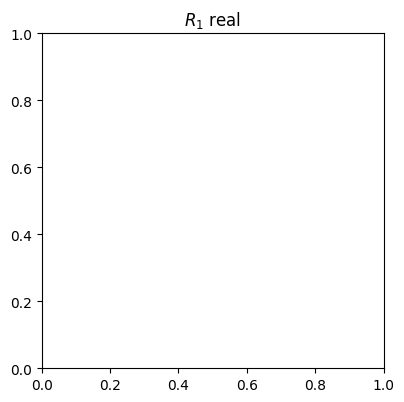

In [ ]:
print("Génération de la figure...")
# Affichage du signal Rephasing (le plus instructif pour l'élargissement inhomogène)


pf.silva_plot(rephasing_spectra, [f1.min(), f1.max(), f2.min(), f2.max()], labels=None,
              title_list=['$R_1$', '$R_2$', '$R_3$', '$R_{rephasing}$'], scale='linear', color_map='PuOr',
              interpolation='spline36', center_scale=False, plot_sum=False, plot_quadrant='4', invert_y=False,
              diagonals=[True, True])

centering data around zero


TypeError: Image data of dtype complex128 cannot be converted to float

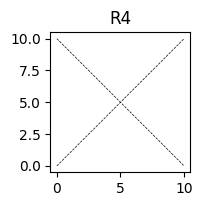

In [28]:
pf.multiplot(response_list, [0, 10, 0, 10], ['t1', 't2'], ['R4', 'R5', 'R6'], 'linear')
pf.multiplot(np.real(spectra_list), extent, ['w1', 'w2'], ['R4', 'R5', 'R6'], 'linear')

In [29]:
pf.silva_plot??

Signature:
pf.silva_plot(
    spectra_list=None,
    scan_range=None,
    labels=None,
    title_list=None,
    scale='linear',
    color_map='PuOr',
    interpolation='spline36',
    center_scale=True,
    plot_sum=True,
    plot_quadrant='All',
    invert_y=True,
    diagonals=[True, True],
)
Source:   
def silva_plot(spectra_list=None, scan_range=None, labels=None, title_list=None, scale='linear', color_map='PuOr',
               interpolation='spline36', center_scale=True, plot_sum=True, plot_quadrant='All', invert_y=True,
               diagonals=[True, True]):
    """
    Plot multiple spectra with real, imaginary and abs values
    :param data: List of spectra or dipole expectation values or any other variable of interest. Must be float data type
    :param scan_range: The min and max of both axis in the format [xmin, xmax, ymin, ymax]
    :param labels: List of label for each axis
    :param title_list: List of titles for each plot
    :param scale: Scaling of the data points, 